## Visualise DESI Gudhi graph edges in a subvolume

This notebook visualises edges from the DESI Gudhi hemisphere-split graph build:

- `points_xyz_mpc_h.npy`
- `edges_combined_idx.npy`

It selects a 3D XYZ box, keeps edges whose endpoints are both inside, then plots a 2D projection with optional subsampling (so plots stay responsive).

By default, it uses the same *thin slab* thickness as the Abacus lightcone notebook (`SLAB_THICK = 25 Mpc/h`) along the perpendicular axis (here: z).


In [4]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# --- paths (edit as needed) ---
OUT_DIR = Path("/pscratch/sd/d/dkololgi/graphweb_desi/outputs/gudhi_hemi_full_alphasq_inf_seed42")
POINTS_XYZ_PATH = OUT_DIR / "points_xyz_mpc_h.npy"
EDGES_PATH = OUT_DIR / "edges_combined_idx.npy"

# --- default box bounds (Mpc/h) ---
# Matches the Abacus cube subvolume bounds used previously.
XLO, XHI = 850.0, 1150.0
YLO, YHI = -150.0, 150.0

# Abacus lightcone viz used a thin slab:
SLAB_THICK = 25.0  # Mpc/h thickness along the perpendicular axis (here: z)
Z_CENTER = 0.5 * (208.0 + 508.0)
ZLO, ZHI = Z_CENTER - 0.5 * SLAB_THICK, Z_CENTER + 0.5 * SLAB_THICK

# --- plotting options ---
PROJ = "xy"  # 'xy', 'xz', or 'yz'
MAX_NODES = 200_000  # 0 disables
MAX_EDGES = 400_000  # 0 disables
SEED = 42

print("POINTS_XYZ_PATH:", POINTS_XYZ_PATH)
print("EDGES_PATH:", EDGES_PATH)
print(f"Box: x[{XLO},{XHI}) y[{YLO},{YHI}) z[{ZLO},{ZHI})")


POINTS_XYZ_PATH: /pscratch/sd/d/dkololgi/graphweb_desi/outputs/gudhi_hemi_full_alphasq_inf_seed42/points_xyz_mpc_h.npy
EDGES_PATH: /pscratch/sd/d/dkololgi/graphweb_desi/outputs/gudhi_hemi_full_alphasq_inf_seed42/edges_combined_idx.npy
Box: x[850.0,1150.0) y[-150.0,150.0) z[345.5,370.5)


In [5]:
# Load artifacts (memmap-friendly)
pts = np.load(POINTS_XYZ_PATH, mmap_mode="r")
edges = np.load(EDGES_PATH, mmap_mode="r")

print("pts:", pts.shape, pts.dtype)
print("edges:", edges.shape, edges.dtype)

x = np.asarray(pts[:, 0], dtype=np.float64)
y = np.asarray(pts[:, 1], dtype=np.float64)
z = np.asarray(pts[:, 2], dtype=np.float64)

in_box = (x >= XLO) & (x < XHI) & (y >= YLO) & (y < YHI) & (z >= ZLO) & (z < ZHI)
idx = np.nonzero(in_box)[0].astype(np.int64)
print(f"Nodes in box: {idx.size:,}")

if idx.size == 0:
    raise ValueError("No nodes in selected box; adjust bounds.")

rng = np.random.default_rng(SEED)
if MAX_NODES and idx.size > int(MAX_NODES):
    idx = np.sort(rng.choice(idx, size=int(MAX_NODES), replace=False))
    print(f"Subsampled nodes: {idx.size:,}")

# Map global -> local index for edge filtering.
local = -np.ones((pts.shape[0],), dtype=np.int32)
local[idx] = np.arange(idx.size, dtype=np.int32)

u = np.asarray(edges[:, 0], dtype=np.int64)
v = np.asarray(edges[:, 1], dtype=np.int64)
lu = local[u]
lv = local[v]
keep = (lu >= 0) & (lv >= 0)
lu = lu[keep]
lv = lv[keep]
print(f"Edges fully in box: {lu.size:,}")

if lu.size == 0:
    raise ValueError("No edges fully inside box; adjust bounds.")

if MAX_EDGES and lu.size > int(MAX_EDGES):
    sel = rng.choice(lu.size, size=int(MAX_EDGES), replace=False)
    lu = lu[sel]
    lv = lv[sel]
    print(f"Subsampled edges: {lu.size:,}")


pts: (13772493, 3) float32
edges: (104676744, 2) int32
Nodes in box: 2,351
Edges fully in box: 13,345


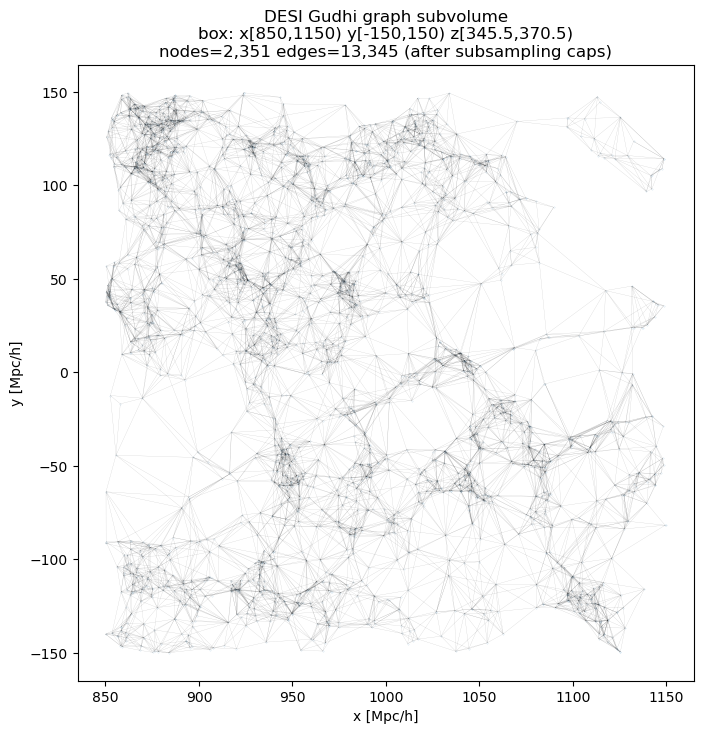

In [6]:
# Build segments + plot
if PROJ == "xy":
    a, b = 0, 1
    xlab, ylab = "x [Mpc/h]", "y [Mpc/h]"
elif PROJ == "xz":
    a, b = 0, 2
    xlab, ylab = "x [Mpc/h]", "z [Mpc/h]"
elif PROJ == "yz":
    a, b = 1, 2
    xlab, ylab = "y [Mpc/h]", "z [Mpc/h]"
else:
    raise ValueError(PROJ)

p = np.asarray(pts[idx], dtype=np.float64)
pa = p[:, a]
pb = p[:, b]

segs = np.stack(
    [
        np.stack([pa[lu], pb[lu]], axis=1),
        np.stack([pa[lv], pb[lv]], axis=1),
    ],
    axis=1,
)

fig, ax = plt.subplots(figsize=(8, 8))
lc = LineCollection(segs, colors="k", linewidths=0.15, alpha=0.25)
ax.add_collection(lc)
ax.scatter(pa, pb, s=0.05, c="tab:blue", alpha=0.25, rasterized=True)

ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
ax.set_title(
    "DESI Gudhi graph subvolume\n"
    f"box: x[{XLO:g},{XHI:g}) y[{YLO:g},{YHI:g}) z[{ZLO:g},{ZHI:g})\n"
    f"nodes={idx.size:,} edges={lu.size:,} (after subsampling caps)"
)
ax.set_aspect("equal", adjustable="box")
# ax.autoscale()
ax.grid(False)
plt.show()
